<a href="https://colab.research.google.com/github/Rizm10/london-rent-vs-earnings/blob/main/london_rent_earnings_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# London Rent vs Earnings — 2025 Data Preparation

This notebook prepares the dataset for the London rent-vs-earnings project by combining:

- **ONS ASHE 2025 provisional, Table 8.1a** — full-time gross weekly pay by home geography
- **London rental statistics, April 2024 to March 2025** — monthly rents by borough and bedroom category

The workflow filters the earnings workbook to the 33 London local authorities, cleans both sources, validates the geography match, merges them by borough, and exports a combined CSV.

The merged dataset keeps **all six bedroom categories** so the analysis can later choose a category without rebuilding the merge.

In [ ]:
import pandas as pd
from pathlib import Path

ASHE_FILE = Path('PROV - Home Geography Table 8.1a   Weekly pay - Gross 2025.xlsx')
RENT_FILE = Path('londonrentalstatsaccessibleq12025.xlsx')
OUTPUT_FILE = Path('london_rent_earnings_2025_merged.csv')

## 1. Load and clean the earnings data

In [ ]:
earnings = pd.read_excel(
    ASHE_FILE,
    sheet_name='Full-Time',
    header=4
)

earnings = earnings.iloc[:, :17].copy()

earnings.columns = [
    'local_authority',
    'code',
    'jobs_thousand',
    'median_weekly_pay_gross_gbp',
    'annual_pct_change_median',
    'mean_weekly_pay_gross_gbp',
    'annual_pct_change_mean',
    'p10_gbp',
    'p20_gbp',
    'p25_gbp',
    'p30_gbp',
    'p40_gbp',
    'p60_gbp',
    'p70_gbp',
    'p75_gbp',
    'p80_gbp',
    'p90_gbp',
]

earnings.head()

,local_authority,code,jobs_thousand,median_weekly_pay_gross_gbp,annual_pct_change_median,mean_weekly_pay_gross_gbp,annual_pct_change_mean,p10_gbp,p20_gbp,p25_gbp,p30_gbp,p40_gbp,p60_gbp,p70_gbp,p75_gbp,p80_gbp,p90_gbp
0,United Kingdom,K02000001,20807,766.6,5.3,920.8,6.2,493.7,554.7,583.5,615.1,688,862.4,977.4,1054.1,1149.9,1473.5
1,Great Britain,K03000001,19865,766.6,4.9,924.3,6.1,494.7,555.8,584.9,617.2,689.9,866.2,981.4,1055.2,1154.6,1482
2,England and Wales,K04000001,18110,766.6,5.1,926.5,6.0,494.2,555.6,584.5,617,689.7,866.3,984.1,1057.5,1159.5,1489.6
3,England,E92000001,17175,769.5,5.0,932.5,6.0,494.9,556,586.1,619.5,689.9,870.4,991.2,1067.5,1166.7,1505.5
4,North East,E12000001,719,692.1,4.6,799.5,4.3,479,521.3,542.1,571.2,623.8,768,867.2,929,997,1215.4


### Filter to London

London local-authority codes in this ASHE table begin with `E09`. Filtering on the code removes aggregate rows such as `London`, `Inner London`, and `Outer London`.

In [ ]:
london_earnings = earnings[
    earnings['code'].astype(str).str.match(r'^E09\d{6}$', na=False)
].copy()

london_earnings['local_authority'] = (
    london_earnings['local_authority']
    .astype(str)
    .str.strip()
)

print('London authorities:', len(london_earnings))
london_earnings[['local_authority', 'code', 'median_weekly_pay_gross_gbp']].head()

London authorities: 33


,local_authority,code,median_weekly_pay_gross_gbp
203,Camden,E09000007,1032.4
204,City of London,E09000001,x
205,Hackney,E09000012,959.3
206,Hammersmith and Fulham,E09000013,917.3
207,Haringey,E09000014,900.8


## 2. Load and clean the borough rental data

In [ ]:
rent = pd.read_excel(
    RENT_FILE,
    sheet_name='2',
    header=2
)

rent = rent.iloc[:, :7].copy()
rent.columns = [
    'borough',
    'bedroom_category',
    'rent_count',
    'rent_mean_gbp',
    'rent_lower_quartile_gbp',
    'rent_median_gbp',
    'rent_upper_quartile_gbp',
]

rent['borough'] = rent['borough'].astype(str).str.strip()

print('Rental rows:', len(rent))
print('Rental boroughs:', rent['borough'].nunique())
print('Bedroom categories:', rent['bedroom_category'].unique().tolist())
rent.head()

Rental rows: 198
Rental boroughs: 33
Bedroom categories: ['Room', 'Studio', 'One Bedroom', 'Two Bedrooms', 'Three Bedrooms', 'Four or More Bedrooms']


,borough,bedroom_category,rent_count,rent_mean_gbp,rent_lower_quartile_gbp,rent_median_gbp,rent_upper_quartile_gbp
0,Barking and Dagenham,Room,-,..,..,..,..
1,Barking and Dagenham,Studio,-,..,..,..,..
2,Barking and Dagenham,One Bedroom,160,1271,1200,1300,1350
3,Barking and Dagenham,Two Bedrooms,250,1557,1400,1550,1750
4,Barking and Dagenham,Three Bedrooms,160,1890,1700,1900,2100


## 3. Validate the borough match before merging

In [ ]:
earnings_boroughs = set(london_earnings['local_authority'])
rental_boroughs = set(rent['borough'])

print('Missing from earnings:', sorted(rental_boroughs - earnings_boroughs))
print('Missing from rental:', sorted(earnings_boroughs - rental_boroughs))

assert len(london_earnings) == 33
assert rent['borough'].nunique() == 33
assert rental_boroughs == earnings_boroughs

Missing from earnings: []
Missing from rental: []


## 4. Merge rent and earnings

In [ ]:
merged = rent.merge(
    london_earnings,
    left_on='borough',
    right_on='local_authority',
    how='left',
    validate='many_to_one'
)

merged = merged.drop(columns='local_authority')

print('Merged rows:', len(merged))
print('Merged boroughs:', merged['borough'].nunique())
merged.head()

Merged rows: 198
Merged boroughs: 33


,borough,bedroom_category,rent_count,rent_mean_gbp,rent_lower_quartile_gbp,rent_median_gbp,rent_upper_quartile_gbp,code,jobs_thousand,median_weekly_pay_gross_gbp,...,p10_gbp,p20_gbp,p25_gbp,p30_gbp,p40_gbp,p60_gbp,p70_gbp,p75_gbp,p80_gbp,p90_gbp
0,Barking and Dagenham,Room,-,..,..,..,..,E09000002,59,754.1,...,497.2,567.8,599.5,631.9,703.8,826.2,920.3,969,1040.6,x
1,Barking and Dagenham,Studio,-,..,..,..,..,E09000002,59,754.1,...,497.2,567.8,599.5,631.9,703.8,826.2,920.3,969,1040.6,x
2,Barking and Dagenham,One Bedroom,160,1271,1200,1300,1350,E09000002,59,754.1,...,497.2,567.8,599.5,631.9,703.8,826.2,920.3,969,1040.6,x
3,Barking and Dagenham,Two Bedrooms,250,1557,1400,1550,1750,E09000002,59,754.1,...,497.2,567.8,599.5,631.9,703.8,826.2,920.3,969,1040.6,x
4,Barking and Dagenham,Three Bedrooms,160,1890,1700,1900,2100,E09000002,59,754.1,...,497.2,567.8,599.5,631.9,703.8,826.2,920.3,969,1040.6,x


### Important data-quality note

The ONS source marks the **City of London** median full-time weekly pay as `x`, meaning the estimate is unreliable for practical purposes. The row is retained in the merged dataset for geographic completeness, but later analysis should convert it to missing rather than treating it as a number.

In [ ]:
merged.loc[
    merged['borough'].eq('City of London'),
    ['borough', 'bedroom_category', 'median_weekly_pay_gross_gbp', 'mean_weekly_pay_gross_gbp']
]

,borough,bedroom_category,median_weekly_pay_gross_gbp,mean_weekly_pay_gross_gbp
36,City of London,Room,x,1804.1
37,City of London,Studio,x,1804.1
38,City of London,One Bedroom,x,1804.1
39,City of London,Two Bedrooms,x,1804.1
40,City of London,Three Bedrooms,x,1804.1
41,City of London,Four or More Bedrooms,x,1804.1


## 5. Export the merged dataset

In [ ]:
merged.to_csv(OUTPUT_FILE, index=False)
print(f'Saved {len(merged)} rows to {OUTPUT_FILE}')

Saved 198 rows to london_rent_earnings_2025_merged.csv


## 6. Create the one-bedroom analysis subset

For the first version of the project, a one-bedroom rent is a cleaner comparison with individual full-time earnings than combining properties of very different sizes. This cell creates the analysis subset but does **not** overwrite the full merged dataset.

In [ ]:
one_bed = merged[merged['bedroom_category'].eq('One Bedroom')].copy()

# Convert ONS suppression/unreliable markers to missing values for analysis.
one_bed['median_weekly_pay_gross_gbp'] = pd.to_numeric(
    one_bed['median_weekly_pay_gross_gbp'],
    errors='coerce'
)
one_bed['rent_median_gbp'] = pd.to_numeric(
    one_bed['rent_median_gbp'],
    errors='coerce'
)

one_bed['monthly_earnings_proxy_gbp'] = (
    one_bed['median_weekly_pay_gross_gbp'] * 52 / 12
)

one_bed['rent_pressure_proxy'] = (
    one_bed['rent_median_gbp'] / one_bed['monthly_earnings_proxy_gbp']
)

print('One-bedroom borough rows:', len(one_bed))
print('Rows with usable earnings:', one_bed['median_weekly_pay_gross_gbp'].notna().sum())

one_bed[
    ['borough', 'rent_median_gbp', 'median_weekly_pay_gross_gbp',
     'monthly_earnings_proxy_gbp', 'rent_pressure_proxy']
].head()

One-bedroom borough rows: 33
Rows with usable earnings: 32


,borough,rent_median_gbp,median_weekly_pay_gross_gbp,monthly_earnings_proxy_gbp,rent_pressure_proxy
2,Barking and Dagenham,1300,754.1,3267.766667,0.397825
8,Barnet,1440,905.4,3923.400000,0.367029
14,Bexley,1250,889.1,3852.766667,0.324442
20,Brent,1750,786.2,3406.866667,0.513668
26,Bromley,1300,964.5,4179.500000,0.311042


## 7. Analyse rent relative to local earnings

With the two datasets merged, the next step is to examine how one-bedroom rents relate to full-time earnings across London.

Two measures are used:

1. **Rent pressure proxy**  
   Median monthly one-bedroom rent as a proportion of estimated median monthly gross earnings.

2. **Rent relative to expected earnings**  
   A simple regression is used to estimate the relationship between local earnings and one-bedroom rent. Residuals are then used to identify boroughs where rent is unusually high or low relative to what would be expected from local earnings.

The **City of London is excluded from calculations requiring median earnings** because its median full-time weekly earnings estimate is suppressed in the ONS dataset.

These measures are intended as comparative indicators rather than complete measures of housing affordability, as they do not account for household income, taxes, benefits, property quality, or household size.

In [ ]:
analysis_df = one_bed.dropna(
    subset=["median_weekly_pay_gross_gbp", "rent_median_gbp"]
).copy()

In [ ]:
from sklearn.linear_model import LinearRegression

X = analysis_df[['median_weekly_pay_gross_gbp']]
y = analysis_df['rent_median_gbp']

model = LinearRegression()
model.fit(X,y)

LinearRegression()

### Regression and residual analysis

To understand whether rents are unusually high or low relative to local earnings, a simple linear regression was fitted using:

- **Input (`X`)**: median full-time weekly gross earnings
- **Target (`y`)**: median monthly one-bedroom rent

The model estimates the expected one-bedroom rent for each borough based on the overall relationship between earnings and rents across London.

After generating the predicted rent values, a **residual** was calculated for each borough:

\[
\text{Residual} = \text{Actual Rent} - \text{Predicted Rent}
\]

Interpretation:

- **Positive residual**: actual rent is higher than expected given local earnings
- **Negative residual**: actual rent is lower than expected
- **Residual near zero**: rent is broadly in line with the London-wide earnings-rent relationship

This allows the analysis to go beyond simply ranking boroughs by rent or earnings and instead identify where housing costs appear unusually high or low relative to local income levels.

In [ ]:
analysis_df["predicted_rent_gbp"] = model.predict(X)
analysis_df["rent_residual_gbp"] = (
analysis_df["rent_median_gbp"] - analysis_df["predicted_rent_gbp"]
)

In [ ]:
analysis_df[
    ["borough", "rent_median_gbp", "predicted_rent_gbp", "rent_residual_gbp"]
].sort_values("rent_residual_gbp", ascending=False)

,borough,rent_median_gbp,predicted_rent_gbp,rent_residual_gbp
194,Westminster,2600,1846.365289,753.634711
116,Kensington and Chelsea,2394,1864.070365,529.929635
20,Brent,1750,1274.566157,475.433843
68,Hackney,2000,1706.220888,293.779112
74,Hammersmith and Fulham,1869,1601.486638,267.513362
50,Ealing,1550,1329.177587,220.822413
110,Islington,2000,1820.181727,179.818273
104,Hounslow,1500,1327.681384,172.318616
146,Newham,1500,1364.338371,135.661629
32,Camden,2000,1888.508356,111.491644


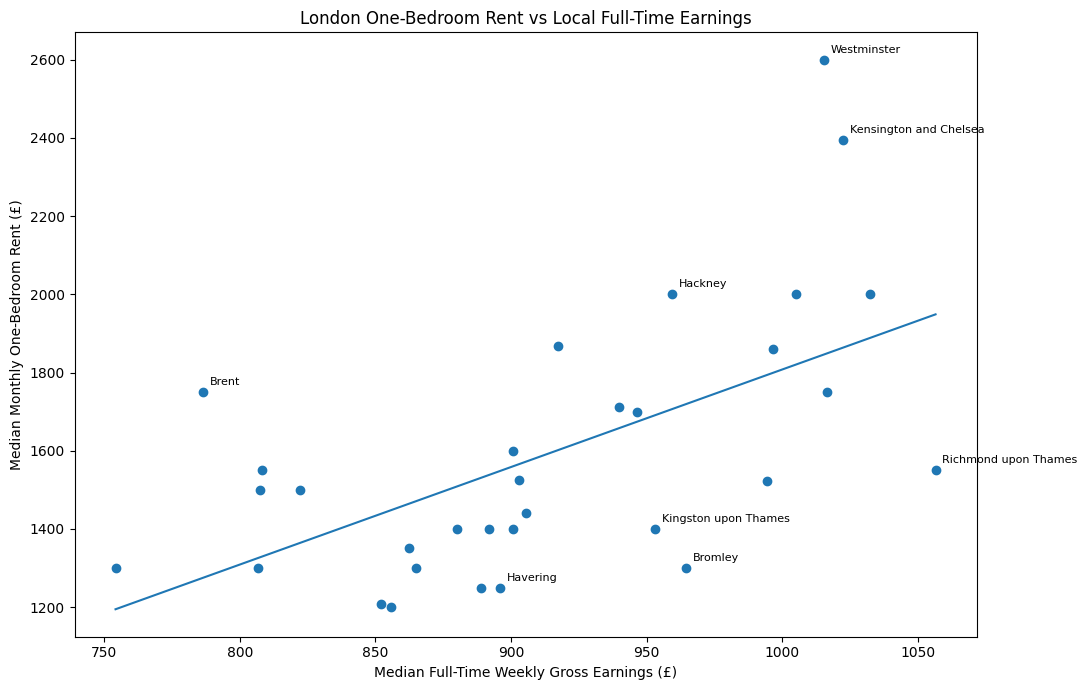

In [ ]:
import matplotlib.pyplot as plt

plot_df = analysis_df.sort_values("median_weekly_pay_gross_gbp")

plt.figure(figsize=(11, 7))

# Actual borough observations
plt.scatter(
    plot_df["median_weekly_pay_gross_gbp"],
    plot_df["rent_median_gbp"]
)

# Regression line
plt.plot(
    plot_df["median_weekly_pay_gross_gbp"],
    plot_df["predicted_rent_gbp"]
)

# Label the 8 biggest absolute residuals
outliers = analysis_df.loc[
    analysis_df["rent_residual_gbp"].abs().nlargest(8).index
]

for _, row in outliers.iterrows():
    plt.annotate(
        row["borough"],
        (
            row["median_weekly_pay_gross_gbp"],
            row["rent_median_gbp"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Median Full-Time Weekly Gross Earnings (£)")
plt.ylabel("Median Monthly One-Bedroom Rent (£)")
plt.title("London One-Bedroom Rent vs Local Full-Time Earnings")

plt.tight_layout()
plt.show()

### Results: Rent relative to local earnings

The regression shows a positive relationship between full-time earnings and one-bedroom rents across London: boroughs with higher local earnings generally also have higher rents.

However, several boroughs sit noticeably above or below the regression line, indicating that their rents differ substantially from what the London-wide earnings-rent relationship would predict.

The largest positive residuals were:

- **Westminster:** approximately **£754 above predicted rent**
- **Kensington and Chelsea:** approximately **£530 above predicted**
- **Brent:** approximately **£475 above predicted**
- **Hackney:** approximately **£294 above predicted**
- **Hammersmith and Fulham:** approximately **£268 above predicted**

This suggests that these boroughs have one-bedroom rents that are relatively high compared with local full-time earnings.

At the other end of the distribution, the largest negative residuals were:

- **Bromley:** approximately **£419 below predicted rent**
- **Richmond upon Thames:** approximately **£399 below predicted**
- **Havering:** approximately **£298 below predicted**
- **Kingston upon Thames:** approximately **£291 below predicted**
- **Bexley:** approximately **£281 below predicted**

These boroughs have rents that are lower than the model would expect given their local earnings levels.

One particularly notable result is **Brent**. Unlike Westminster or Kensington and Chelsea, its high residual is not simply associated with extremely high local earnings or rents. Its median one-bedroom rent is substantially higher than the regression would predict from local earnings, making it one of the strongest relative outliers in the analysis.

These residuals should not be interpreted as complete measures of housing affordability. They instead show where rents are unusually high or low **relative to the earnings-rent relationship observed across London**.

In [ ]:
rent_pressure_ranked = analysis_df[
    ["borough", "rent_median_gbp", "monthly_earnings_proxy_gbp", "rent_pressure_proxy"]
].sort_values("rent_pressure_proxy", ascending=False)

rent_pressure_ranked

,borough,rent_median_gbp,monthly_earnings_proxy_gbp,rent_pressure_proxy
194,Westminster,2600,4400.500000,0.590842
116,Kensington and Chelsea,2394,4431.266667,0.540252
20,Brent,1750,3406.866667,0.513668
68,Hackney,2000,4156.966667,0.481120
74,Hammersmith and Fulham,1869,3974.966667,0.470193
110,Islington,2000,4355.000000,0.459242
32,Camden,2000,4473.733333,0.447054
50,Ealing,1550,3501.766667,0.442634
176,Tower Hamlets,1860,4318.600000,0.430695
104,Hounslow,1500,3499.166667,0.428673


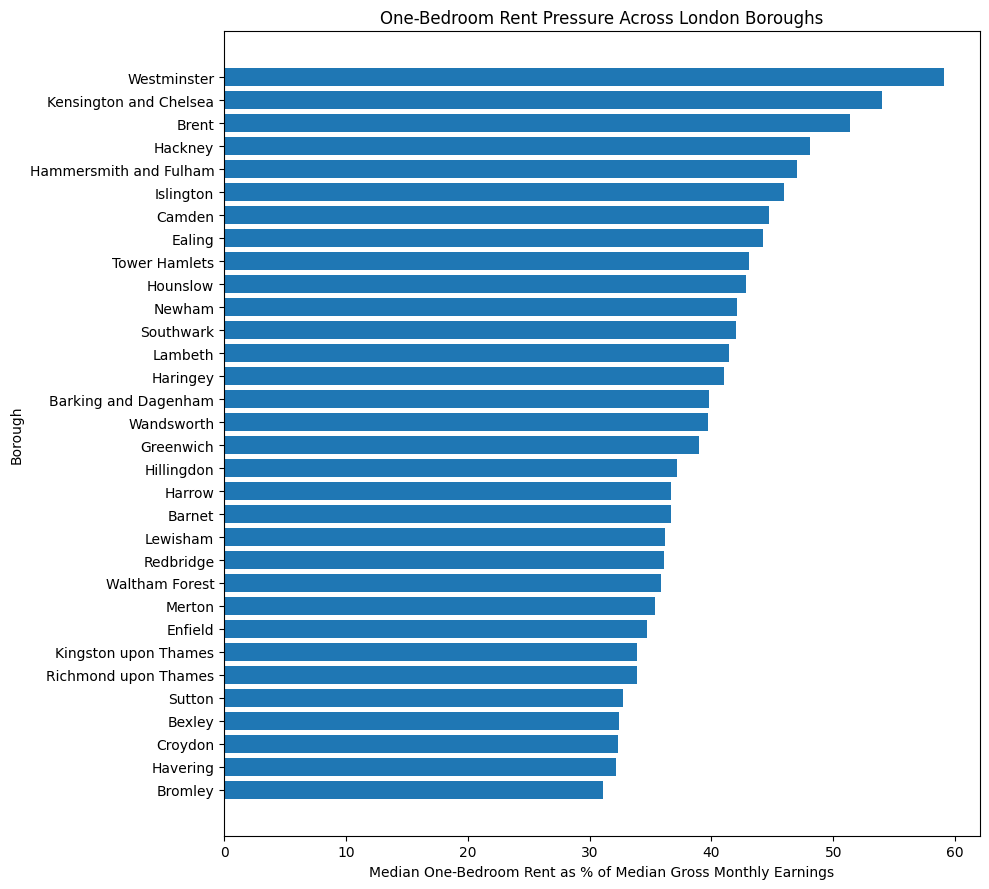

In [ ]:
plt.figure(figsize=(10, 9))

ranked = rent_pressure_ranked.sort_values(
    "rent_pressure_proxy",
    ascending=True
)

plt.barh(
    ranked["borough"],
    ranked["rent_pressure_proxy"] * 100
)

plt.xlabel("Median One-Bedroom Rent as % of Median Gross Monthly Earnings")
plt.ylabel("Borough")
plt.title("One-Bedroom Rent Pressure Across London Boroughs")

plt.tight_layout()
plt.show()

### Rent pressure across London boroughs

A second measure was used to compare one-bedroom rents directly with estimated median gross monthly earnings.

The **rent pressure proxy** is calculated as:

\[
\text{Rent Pressure} =
\frac{\text{Median Monthly One-Bedroom Rent}}
{\text{Estimated Median Gross Monthly Earnings}}
\]

The highest values were:

- **Westminster:** 59.1%
- **Kensington and Chelsea:** 54.0%
- **Brent:** 51.4%
- **Hackney:** 48.1%
- **Hammersmith and Fulham:** 47.0%

At the lower end:

- **Bromley:** 31.1%
- **Havering:** 32.2%
- **Croydon:** 32.4%
- **Bexley:** 32.4%
- **Sutton:** 32.7%

The ranking broadly supports the residual analysis. Boroughs such as Westminster, Kensington and Chelsea, Brent and Hackney appear near the top under both approaches.

**Brent is particularly notable**, with median one-bedroom rent equivalent to approximately **51% of estimated median gross monthly earnings**, despite not having the exceptionally high earnings seen in some central London boroughs.

This ratio is a comparative proxy rather than a complete affordability measure. It uses gross individual earnings and does not account for taxes, household income, benefits, shared housing costs or other living expenses.

In [ ]:
r2 = model.score(X, y)

print(f"R²: {r2:.3f}")
print(f"Coefficient: £{model.coef_[0]:.2f}")
print(f"Intercept: £{model.intercept_:.2f}")

R²: 0.347
Coefficient: £2.49
Intercept: £-685.96


### Strength of the earnings-rent relationship

The regression produced an **R² of 0.347**, meaning median full-time weekly earnings explain approximately **34.7% of the observed variation in median one-bedroom rents across the 32 London boroughs included in the analysis**.

The fitted coefficient was **2.49**, indicating that within this dataset, a £1 increase in median weekly earnings is associated with approximately £2.49 higher median monthly one-bedroom rent.

However, earnings alone leave a substantial amount of variation unexplained. Approximately 65% of the variation in rents is not captured by this one-variable model, suggesting that factors beyond local earnings play an important role in differences between borough rental markets.

The regression is used here as a comparative benchmark rather than a causal model. The coefficient should therefore not be interpreted as evidence that higher local earnings directly cause rents to increase by this amount.

The fitted intercept of approximately **-£686** has little practical interpretation because an earnings value of £0 lies well outside the range observed in the borough data.

## 8. Final findings

This analysis compared median one-bedroom rents with median full-time weekly earnings across London local authorities.

The main findings were:

- Boroughs with higher local earnings generally also have higher one-bedroom rents, but the relationship is only moderate.
- Median full-time earnings explained approximately **34.7%** of the variation in one-bedroom rents.
- **Westminster, Kensington and Chelsea, Brent, Hackney, and Hammersmith and Fulham** had the largest positive rent residuals, meaning rents were substantially higher than predicted from local earnings.
- **Bromley, Richmond upon Thames, Havering, Kingston upon Thames, and Bexley** had the largest negative residuals, meaning rents were lower than predicted from the London-wide relationship.
- The rent-pressure proxy produced a similar ranking, with Westminster, Kensington and Chelsea, Brent, Hackney, and Hammersmith and Fulham again appearing near the top.
- **Brent was one of the strongest relative outliers**, with median one-bedroom rent equivalent to roughly **51% of estimated median gross monthly earnings**.

Overall, local earnings are related to rental costs, but they explain only part of the differences between London boroughs.

## Limitations

This analysis is intended as a comparative indicator rather than a complete measure of housing affordability.

Important limitations include:

- Earnings are based on **median full-time gross pay**, not disposable income.
- Rent is based on **median one-bedroom asking/recorded rents**, not the housing costs faced by every household.
- Household income, taxes, benefits, savings, shared accommodation, and household size are not included.
- The analysis is cross-sectional and does not establish causation.
- The regression contains only one explanatory variable, so many factors affecting rents are omitted.
- Differences in property quality, transport access, neighbourhood characteristics, housing supply, and demand are not explicitly modelled.
- The **City of London** is excluded from earnings-based calculations because its median earnings estimate is suppressed in the ONS source.
- Both datasets are based on observed/sample data rather than complete populations. Some earnings and rental observations may be missing because not all employers, landlords, agents or other data providers supplied usable information. This means the reported medians may not perfectly represent every worker or rental property within each borough.
- Some estimates are also suppressed or considered unreliable where the available sample is too small or statistically weak. For example, the City of London median earnings estimate could not be used in the analysis.
- Sample sizes vary between boroughs. The one-bedroom rental dataset contains between approximately **150 and 890 observations per borough**, while the earnings estimates represent differing numbers of jobs. As a result, the precision of the borough-level estimates may vary, particularly for areas with smaller samples.


The results should therefore be interpreted as showing where rents are unusually high or low relative to local earnings, rather than identifying definitively affordable or unaffordable boroughs.

In [ ]:
print("Rows used in regression:", len(analysis_df))
print("Unique boroughs:", analysis_df["borough"].nunique())

print("\nMissing values:")
print(
    analysis_df[
        [
            "median_weekly_pay_gross_gbp",
            "rent_median_gbp",
            "predicted_rent_gbp",
            "rent_residual_gbp",
            "rent_pressure_proxy"
        ]
    ].isna().sum()
)

print("\nDuplicate boroughs:")
print(analysis_df["borough"].duplicated().sum())

print("\nResidual sum:")
print(round(analysis_df["rent_residual_gbp"].sum(), 6))

Rows used in regression: 32
Unique boroughs: 32

Missing values:
median_weekly_pay_gross_gbp    0
rent_median_gbp                0
predicted_rent_gbp             0
rent_residual_gbp              0
rent_pressure_proxy            0
dtype: int64

Duplicate boroughs:
0

Residual sum:
0.0


In [ ]:
qa_df = analysis_df.copy()

qa_df["rent_count"] = pd.to_numeric(
    qa_df["rent_count"],
    errors="coerce"
)

qa_df["jobs_thousand"] = pd.to_numeric(
    qa_df["jobs_thousand"],
    errors="coerce"
)

print("Rental sample range:")
print("Min:", qa_df["rent_count"].min())
print("Max:", qa_df["rent_count"].max())

print("\nEarnings job-count range (thousands):")
print("Min:", qa_df["jobs_thousand"].min())
print("Max:", qa_df["jobs_thousand"].max())

print("\nSmallest rental samples:")
display(
    qa_df[
        ["borough", "rent_count", "jobs_thousand"]
    ].sort_values("rent_count").head(10)
)

Rental sample range:
Min: 150
Max: 890

Earnings job-count range (thousands):
Min: 39
Max: 132

Smallest rental samples:


,borough,rent_count,jobs_thousand
14,Bexley,150,77
2,Barking and Dagenham,160,59
56,Enfield,230,83
122,Kingston upon Thames,240,52
140,Merton,240,74
158,Richmond upon Thames,240,55
92,Havering,250,78
68,Hackney,290,77
80,Haringey,290,77
32,Camden,310,70


In [ ]:
final_results = analysis_df[
    [
        "borough",
        "rent_median_gbp",
        "median_weekly_pay_gross_gbp",
        "monthly_earnings_proxy_gbp",
        "rent_pressure_proxy",
        "predicted_rent_gbp",
        "rent_residual_gbp"
    ]
].copy()

final_results = final_results.sort_values(
    "rent_residual_gbp",
    ascending=False
)

final_results.to_csv(
    "london_rent_vs_earnings_final_results.csv",
    index=False
)

print("Final analysis frozen.")
print("Rows:", len(final_results))

Final analysis frozen.
Rows: 32
